In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold
import seaborn as sns

def mean_squared_error_custom(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error_custom(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


In [43]:
class DecisionTreeRegressor:
    
    def __init__(self, max_depth=None):
        self.max_depth = max_depth

    def fit(self, X, y):
        self.tree_ = self._build_tree(X, y)
    
    def _build_tree(self, X, y, depth=0):
        if self.max_depth is not None and depth >= self.max_depth:
            return np.mean(y)

        if len(np.unique(y)) == 1:
            return y[0]

        n_samples, n_features = X.shape
        best_split = None
        best_mse = float('inf')

        for feature_index in range(n_features):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                left_mask = X[:, feature_index] <= threshold
                right_mask = ~left_mask
                left_y, right_y = y[left_mask], y[right_mask]

                if len(left_y) == 0 or len(right_y) == 0:
                    continue

                mse = (
                    len(left_y) * np.var(left_y) +
                    len(right_y) * np.var(right_y)
                )

                if mse < best_mse:
                    best_mse = mse
                    best_split = (feature_index, threshold)

        if best_split is None:
            return np.mean(y)

        feature_index, threshold = best_split
        left_mask = X[:, feature_index] <= threshold
        right_mask = ~left_mask

        left_tree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_tree = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'feature_index': feature_index,
            'threshold': threshold,
            'left': left_tree,
            'right': right_tree
        }

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree_) for x in X])

    def _predict_one(self, x, tree):
        if not isinstance(tree, dict):
            return tree

        feature_index = tree['feature_index']
        threshold = tree['threshold']

        if x[feature_index] <= threshold:
            return self._predict_one(x, tree['left'])
        else:
            return self._predict_one(x, tree['right'])


In [44]:
class BaggingRegressor:
    def __init__(self, base_estimator, n_estimators=10):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.models = []

    def fit(self, X, y):
        self.models = []
        for _ in range(self.n_estimators):
            indices = np.random.choice(len(X), len(X), replace=True)
            X_sample = X[indices]
            y_sample = y[indices]
            model = DecisionTreeRegressor(max_depth=5)
            model.fit(X_sample, y_sample)
            self.models.append(model)

    def predict(self, X):
        predictions = np.zeros((self.n_estimators, len(X)))
        for i, model in enumerate(self.models):
            predictions[i] = model.predict(X)
        return np.mean(predictions, axis=0)

In [45]:
class RandomForestRegressor:
    def __init__(self, n_estimators=10, max_depth=None, max_features=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.models = []

    def fit(self, X, y):
        self.models = []
        for _ in range(self.n_estimators):
            indices = np.random.choice(len(X), len(X), replace=True)
            features = np.random.choice(X.shape[1], self.max_features, replace=False)
            X_sample = X[indices][:, features]
            y_sample = y[indices]
            model = DecisionTreeRegressor(max_depth=self.max_depth)
            model.fit(X_sample, y_sample)
            self.models.append((model, features))

    def predict(self, X):
        predictions = np.zeros((self.n_estimators, len(X)))
        for i, (model, features) in enumerate(self.models):
            predictions[i] = model.predict(X[:, features])
        return np.mean(predictions, axis=0)

In [46]:
class GradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []
        self.loss = []

    def fit(self, X, y):
        self.models = []
        residual = y
        for _ in range(self.n_estimators):
            model = DecisionTreeRegressor(max_depth=self.max_depth)
            model.fit(X, residual)
            self.models.append(model)
            prediction = model.predict(X)
            residual -= self.learning_rate * prediction

    def predict(self, X):
        predictions = np.zeros(len(X))
        for model in self.models:
            predictions += self.learning_rate * model.predict(X)
        return predictions



In [47]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
def cross_validate_model(model, X, y, k_folds=4):
    kf = KFold(n_splits=k_folds)
    mse_train_scores = []
    mae_train_scores = []
    mse_val_scores = []
    mae_val_scores = []
    
    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        mse_train = mean_squared_error_custom(y_train, y_train_pred)
        mae_train = mean_absolute_error_custom(y_train, y_train_pred)
        mse_val = mean_squared_error_custom(y_val, y_val_pred)
        mae_val = mean_absolute_error_custom(y_val, y_val_pred)
        
        mse_train_scores.append(mse_train)
        mae_train_scores.append(mae_train)
        mse_val_scores.append(mse_val)
        mae_val_scores.append(mae_val)
        
    return (np.mean(mse_train_scores), np.mean(mae_train_scores),
            np.mean(mse_val_scores), np.mean(mae_val_scores))

In [49]:
def plot_errors(results, model_name, param_name):
    param_values, mse_train, mae_train, mse_val, mae_val = zip(*results)
    
    plt.figure(figsize=(14, 8))

    
    plt.subplot(2, 2, 1)
    plt.plot(param_values, mse_train, marker='o', label='Train MSE')
    plt.plot(param_values, mse_val, marker='o', label='Val MSE', linestyle='--')
    plt.title(f'{model_name} - MSE')
    plt.xlabel(param_name)
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(param_values, mae_train, marker='o', label='Train MAE')
    plt.plot(param_values, mae_val, marker='o', label='Val MAE', linestyle='--')
    plt.title(f'{model_name} - MAE')
    plt.xlabel(param_name)
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [50]:
param_grids = {
    "Decision Tree": {"max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10]},
    "Bagging": {"n_estimators": [10, 15, 20, 25, 30]},
    "Random Forest": {"n_estimators": [10, 20, 30], "max_features": [3, 5, 7]},
    "Gradient Boosting": {"n_estimators": [50, 100, 150], "learning_rate": [0.01, 0.1, 0.2], "max_depth": [3, 5, 7]}
}

Decision Tree Tuning:
max_depth: 2, Train MSE: 3277.9934, Train MAE: 46.5418, Val MSE: 3829.5790, Val MAE: 50.2300
max_depth: 3, Train MSE: 2738.3513, Train MAE: 42.0728, Val MSE: 4067.5702, Val MAE: 51.1692
max_depth: 4, Train MSE: 2282.8307, Train MAE: 37.7239, Val MSE: 4268.1208, Val MAE: 52.3170
max_depth: 5, Train MSE: 1800.5256, Train MAE: 32.5375, Val MSE: 4479.9681, Val MAE: 54.5133
max_depth: 6, Train MSE: 1271.3455, Train MAE: 26.2905, Val MSE: 5420.1836, Val MAE: 58.9139
max_depth: 7, Train MSE: 853.7624, Train MAE: 20.1513, Val MSE: 5911.2291, Val MAE: 60.6305
max_depth: 8, Train MSE: 524.0483, Train MAE: 14.6731, Val MSE: 6136.5593, Val MAE: 62.3772
max_depth: 9, Train MSE: 290.2431, Train MAE: 9.2427, Val MSE: 6449.1939, Val MAE: 63.7510
max_depth: 10, Train MSE: 151.6436, Train MAE: 5.5075, Val MSE: 6584.0452, Val MAE: 64.8949


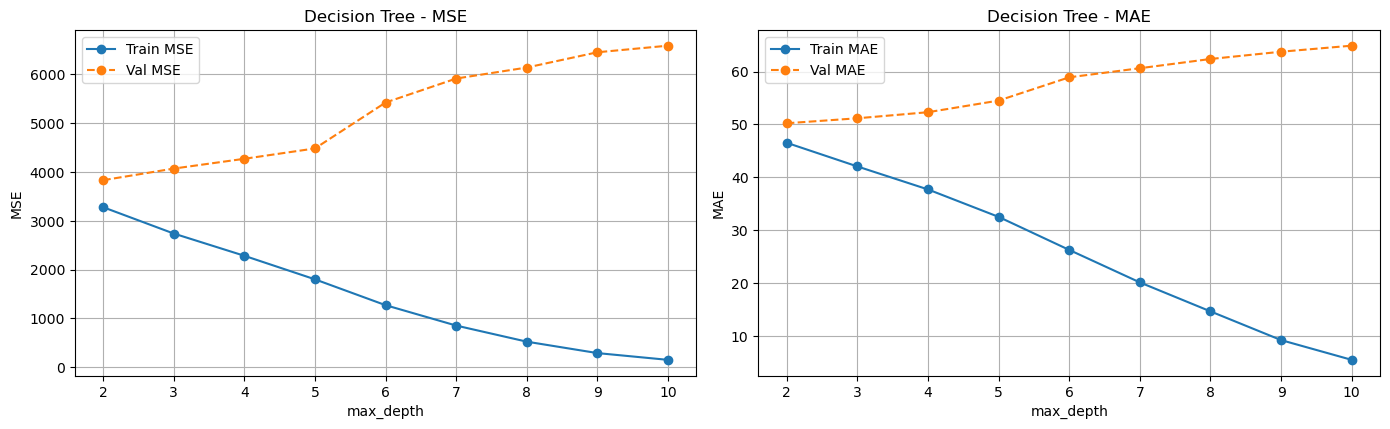

In [51]:
print("Decision Tree Tuning:")
dt_results = []
for max_depth in param_grids["Decision Tree"]["max_depth"]:
    model = DecisionTreeRegressor(max_depth=max_depth)
    mse_train, mae_train, mse_val, mae_val = cross_validate_model(model, X_train, y_train)
    dt_results.append((max_depth, mse_train, mae_train, mse_val, mae_val))
    print(f"max_depth: {max_depth}, Train MSE: {mse_train:.4f}, Train MAE: {mae_train:.4f}, Val MSE: {mse_val:.4f}, Val MAE: {mae_val:.4f}")
plot_errors(dt_results, "Decision Tree", "max_depth")


Bagging Regressor Tuning:
n_estimators: 10, Train MSE: 1504.0281, Train MAE: 31.5482, Val MSE: 3625.7168, Val MAE: 48.8776
n_estimators: 15, Train MSE: 1514.0573, Train MAE: 31.7798, Val MSE: 3537.1054, Val MAE: 48.8758
n_estimators: 20, Train MSE: 1458.6369, Train MAE: 31.3508, Val MSE: 3452.3622, Val MAE: 47.4267
n_estimators: 25, Train MSE: 1446.2979, Train MAE: 31.3792, Val MSE: 3493.3485, Val MAE: 48.0539
n_estimators: 30, Train MSE: 1436.2893, Train MAE: 31.4419, Val MSE: 3527.1169, Val MAE: 48.2270


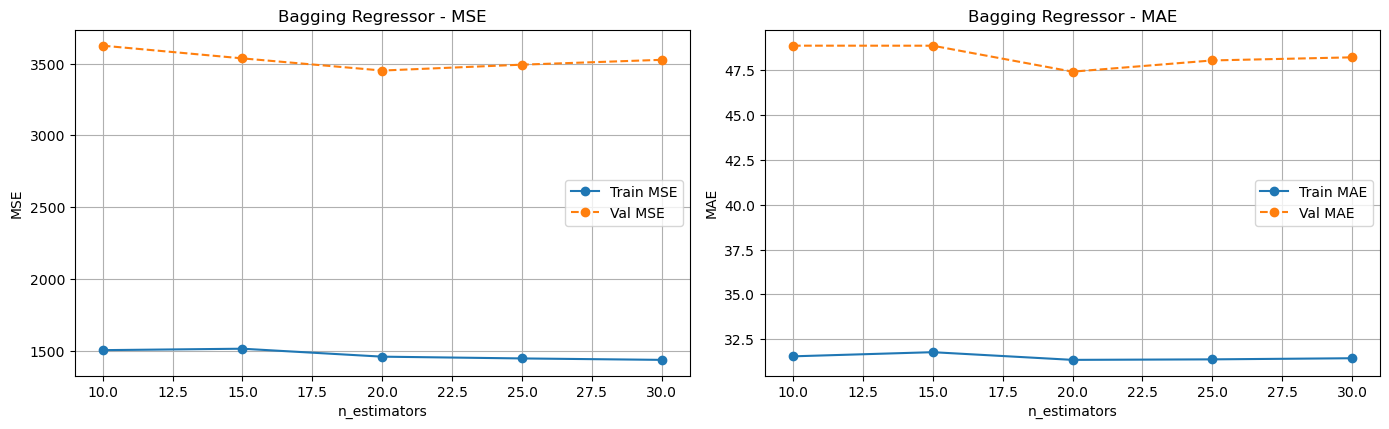

In [52]:
print("Bagging Regressor Tuning:")
bagging_results = []
for n_estimators in param_grids["Bagging"]["n_estimators"]:
    model = BaggingRegressor(DecisionTreeRegressor(max_depth=5), n_estimators=n_estimators)
    mse_train, mae_train, mse_val, mae_val = cross_validate_model(model, X_train, y_train)
    bagging_results.append((n_estimators, mse_train, mae_train, mse_val, mae_val))
    print(f"n_estimators: {n_estimators}, Train MSE: {mse_train:.4f}, Train MAE: {mae_train:.4f}, Val MSE: {mse_val:.4f}, Val MAE: {mae_val:.4f}")
plot_errors(bagging_results, "Bagging Regressor", "n_estimators")

In [53]:
def plot_heatmap(results, title, x_label, y_label, z_label, error_type, cmap="viridis"):
    results = np.array(results)
    x_values = np.unique(results[:, 0])
    y_values = np.unique(results[:, 1])
    

    heatmap_data = np.zeros((len(y_values), len(x_values)))
    for i, y_val in enumerate(y_values):
        for j, x_val in enumerate(x_values):
   
            mask = (results[:, 0] == x_val) & (results[:, 1] == y_val)
            if np.sum(mask) > 0:
           
                heatmap_data[i, j] = results[mask, error_type][0]  

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".4f", xticklabels=x_values, yticklabels=y_values, cmap=cmap)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


Random Forest Regressor Tuning:
n_estimators: 10, max_features: 3, Train MSE: 2217.9550, Train MAE: 39.4290, Val MSE: 4163.0474, Val MAE: 54.4020
n_estimators: 10, max_features: 5, Train MSE: 1705.3259, Train MAE: 34.2157, Val MSE: 3695.5664, Val MAE: 49.8121
n_estimators: 10, max_features: 7, Train MSE: 1592.7261, Train MAE: 33.1173, Val MSE: 3514.5855, Val MAE: 48.7582
n_estimators: 20, max_features: 3, Train MSE: 2106.5049, Train MAE: 38.6968, Val MSE: 3761.3420, Val MAE: 51.2708
n_estimators: 20, max_features: 5, Train MSE: 1655.4680, Train MAE: 34.2744, Val MSE: 3472.9572, Val MAE: 49.6181
n_estimators: 20, max_features: 7, Train MSE: 1551.9815, Train MAE: 32.6509, Val MSE: 3360.7416, Val MAE: 47.7117
n_estimators: 30, max_features: 3, Train MSE: 2046.6001, Train MAE: 38.4744, Val MSE: 3774.7990, Val MAE: 52.0907
n_estimators: 30, max_features: 5, Train MSE: 1630.4723, Train MAE: 34.1382, Val MSE: 3433.4572, Val MAE: 48.9600
n_estimators: 30, max_features: 7, Train MSE: 1487.0501,

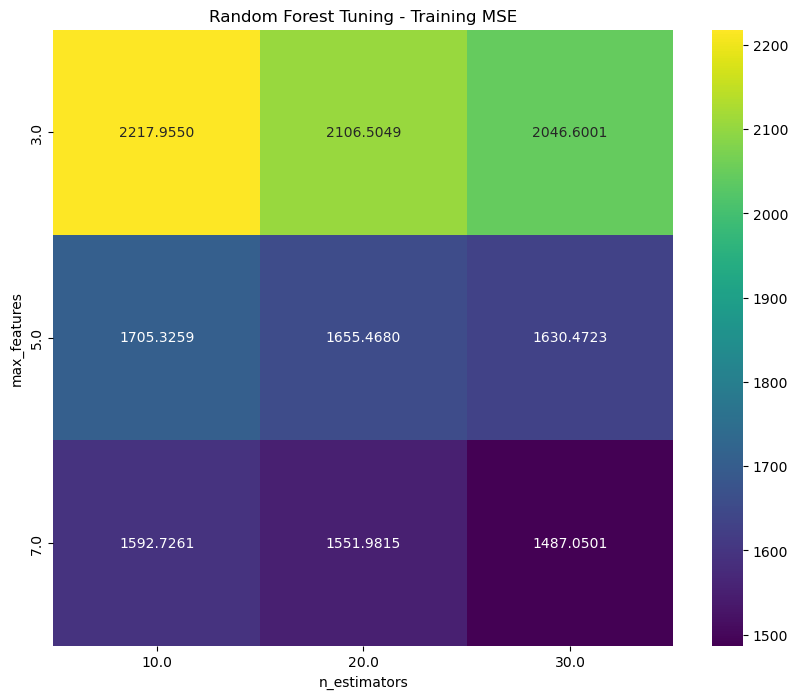

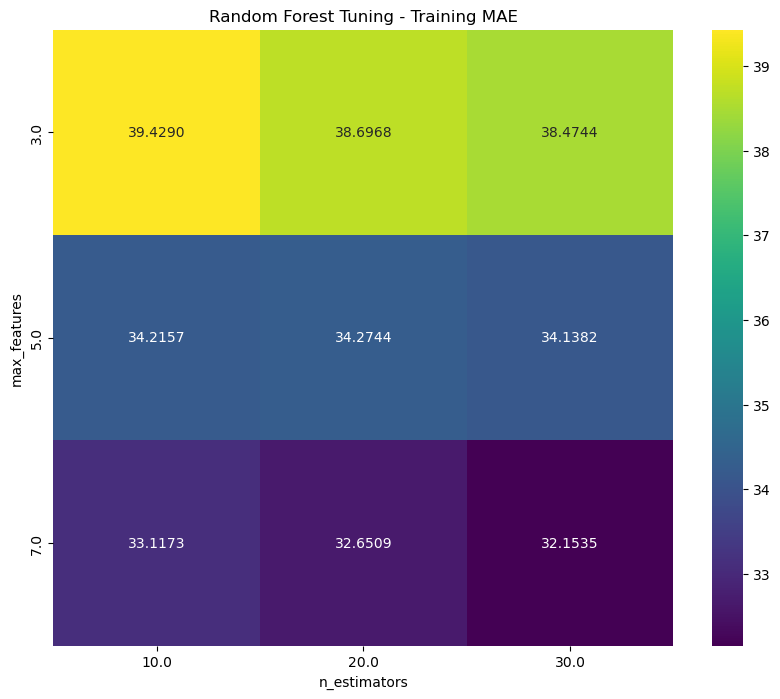

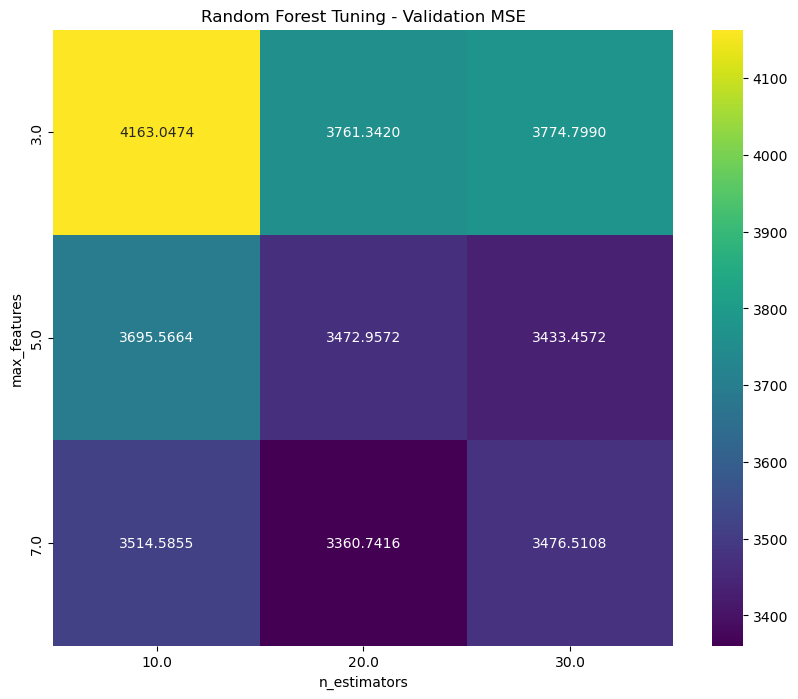

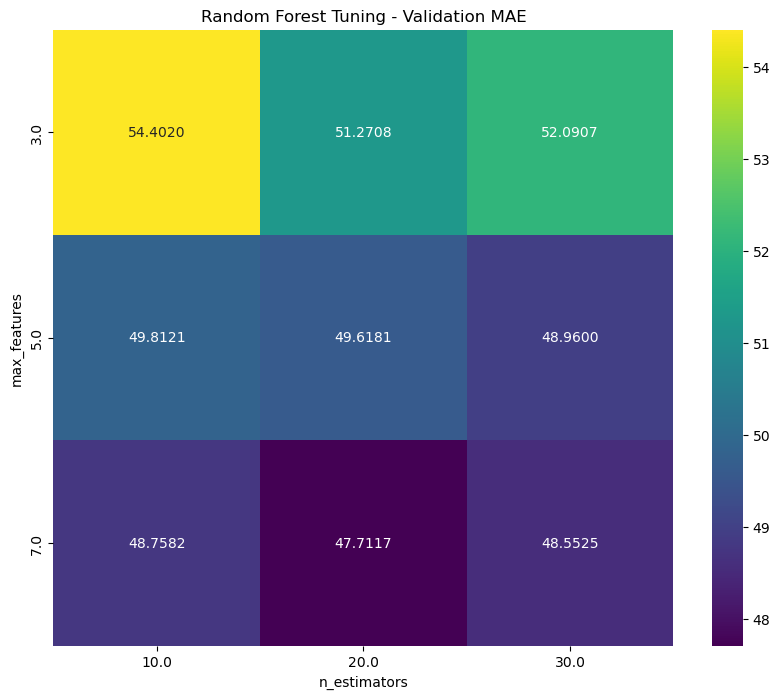

In [54]:
print("Random Forest Regressor Tuning:")
rf_results = []
for n_estimators in param_grids["Random Forest"]["n_estimators"]:
    for max_features in param_grids["Random Forest"]["max_features"]:
        model = RandomForestRegressor(n_estimators=n_estimators, max_depth=5, max_features=max_features)
        mse_train, mae_train, mse_val, mae_val = cross_validate_model(model, X_train, y_train)
        rf_results.append((n_estimators, max_features, mse_train, mae_train, mse_val, mae_val))
        print(f"n_estimators: {n_estimators}, max_features: {max_features}, Train MSE: {mse_train:.4f}, Train MAE: {mae_train:.4f}, Val MSE: {mse_val:.4f}, Val MAE: {mae_val:.4f}")


rf_results = np.array(rf_results)


plot_heatmap(rf_results, 
             title="Random Forest Tuning - Training MSE", 
             x_label="n_estimators", 
             y_label="max_features", 
             z_label="Training MSE", 
             error_type=2)  


plot_heatmap(rf_results, 
             title="Random Forest Tuning - Training MAE", 
             x_label="n_estimators", 
             y_label="max_features", 
             z_label="Training MAE", 
             error_type=3)  


plot_heatmap(rf_results, 
             title="Random Forest Tuning - Validation MSE", 
             x_label="n_estimators", 
             y_label="max_features", 
             z_label="Validation MSE", 
             error_type=4) 


plot_heatmap(rf_results, 
             title="Random Forest Tuning - Validation MAE", 
             x_label="n_estimators", 
             y_label="max_features", 
             z_label="Validation MAE", 
             error_type=5)  


Gradient Boosting Regressor Tuning:
n_estimators: 50, learning_rate: 0.01, max_depth: 3, Train MSE: 3686.4441, Train MAE: 47.4662, Val MSE: 13069.7691, Val MAE: 93.4632
n_estimators: 50, learning_rate: 0.01, max_depth: 5, Train MSE: 2734.3196, Train MAE: 41.4485, Val MSE: 12954.5452, Val MAE: 93.1830
n_estimators: 50, learning_rate: 0.01, max_depth: 7, Train MSE: 1874.6317, Train MAE: 35.4047, Val MSE: 13114.7992, Val MAE: 93.7062
n_estimators: 50, learning_rate: 0.1, max_depth: 3, Train MSE: 26684.0438, Train MAE: 152.1555, Val MSE: 3523.4233, Val MAE: 48.0202
n_estimators: 50, learning_rate: 0.1, max_depth: 5, Train MSE: 27290.9640, Train MAE: 152.1491, Val MSE: 3782.6155, Val MAE: 48.8350
n_estimators: 50, learning_rate: 0.1, max_depth: 7, Train MSE: 28590.9227, Train MAE: 152.1491, Val MSE: 4424.2322, Val MAE: 52.6389
n_estimators: 50, learning_rate: 0.2, max_depth: 3, Train MSE: 27549.9211, Train MAE: 153.7294, Val MSE: 3684.8682, Val MAE: 48.3771
n_estimators: 50, learning_rate: 

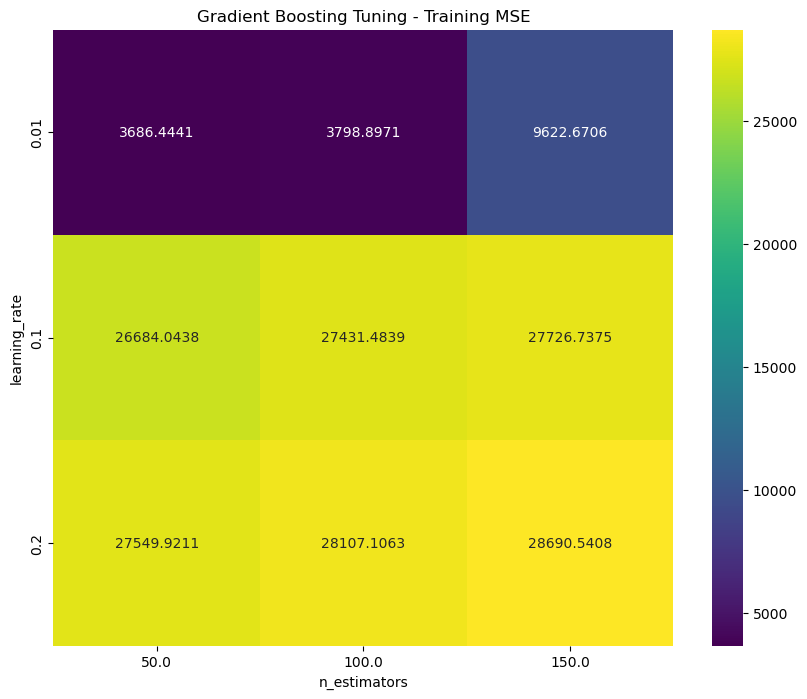

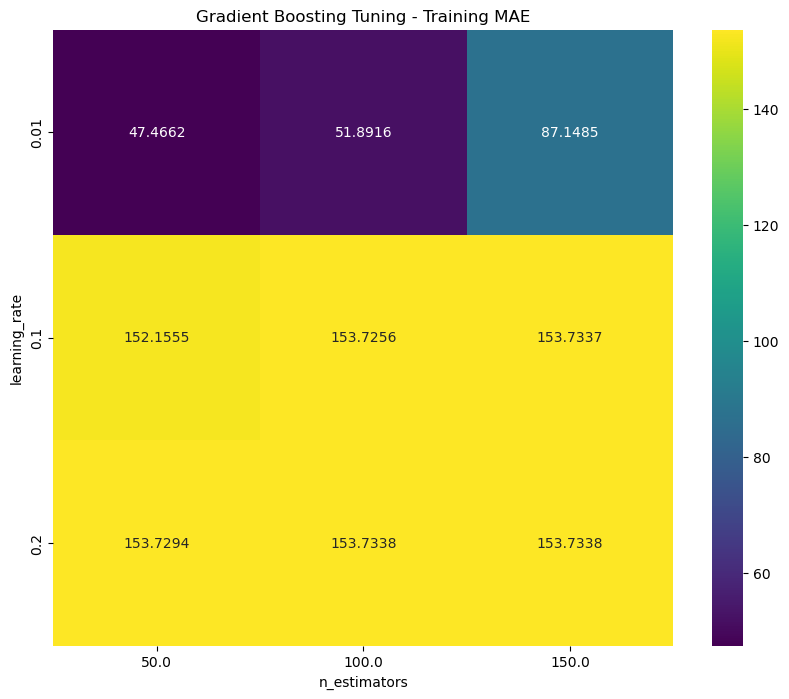

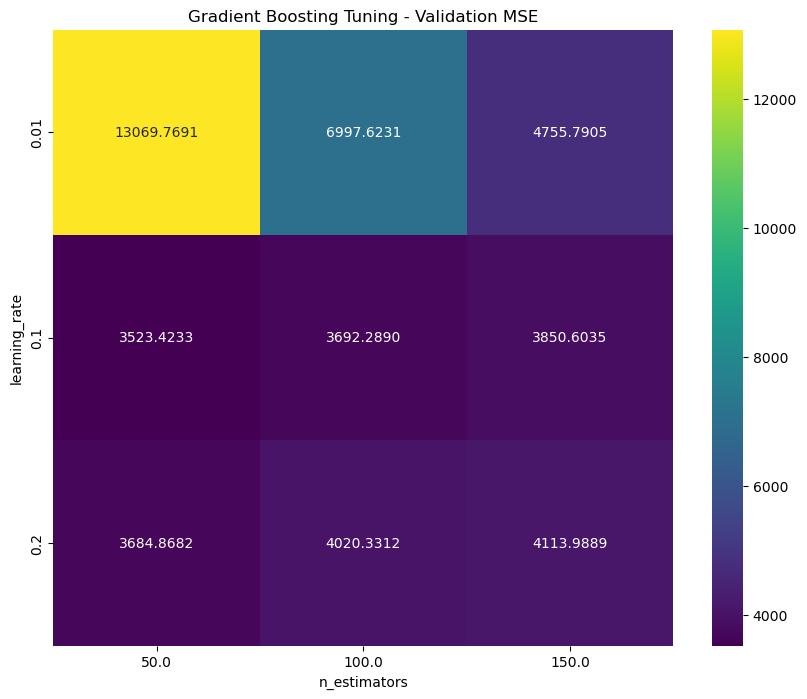

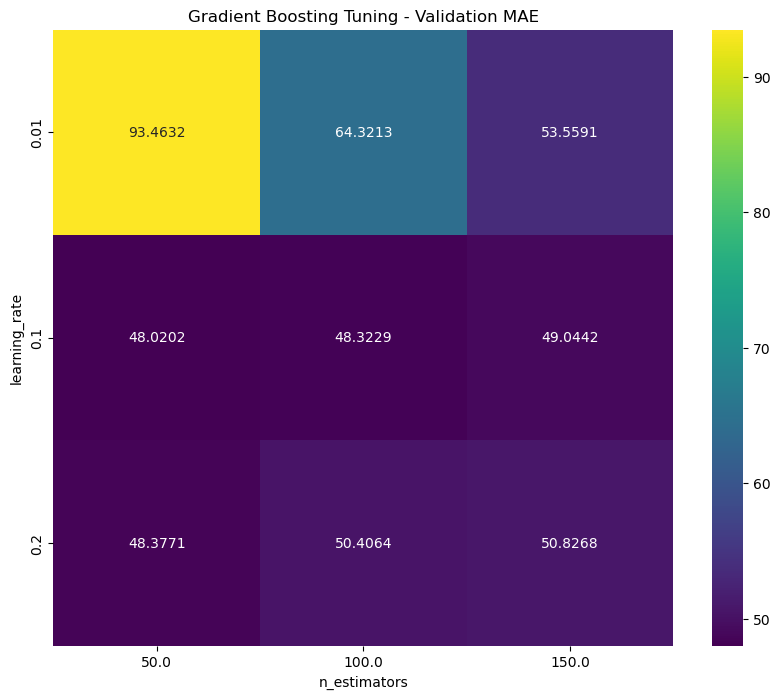

In [55]:
print("Gradient Boosting Regressor Tuning:")
gb_results = []
for n_estimators in param_grids["Gradient Boosting"]["n_estimators"]:
    for learning_rate in param_grids["Gradient Boosting"]["learning_rate"]:
        for max_depth in param_grids["Gradient Boosting"]["max_depth"]:
            model = GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth)
            mse_train, mae_train, mse_val, mae_val = cross_validate_model(model, X_train, y_train)
            gb_results.append((n_estimators, learning_rate, max_depth, mse_train, mae_train, mse_val, mae_val))
            print(f"n_estimators: {n_estimators}, learning_rate: {learning_rate}, max_depth: {max_depth}, Train MSE: {mse_train:.4f}, Train MAE: {mae_train:.4f}, Val MSE: {mse_val:.4f}, Val MAE: {mae_val:.4f}")


gb_results = np.array(gb_results)


plot_heatmap(gb_results, 
             title="Gradient Boosting Tuning - Training MSE", 
             x_label="n_estimators", 
             y_label="learning_rate", 
             z_label="Training MSE", 
             error_type=3)  


plot_heatmap(gb_results, 
             title="Gradient Boosting Tuning - Training MAE", 
             x_label="n_estimators", 
             y_label="learning_rate", 
             z_label="Training MAE", 
             error_type=4)  


plot_heatmap(gb_results, 
             title="Gradient Boosting Tuning - Validation MSE", 
             x_label="n_estimators", 
             y_label="learning_rate", 
             z_label="Validation MSE", 
             error_type=5)  


plot_heatmap(gb_results, 
             title="Gradient Boosting Tuning - Validation MAE", 
             x_label="n_estimators", 
             y_label="learning_rate", 
             z_label="Validation MAE", 
             error_type=6)  


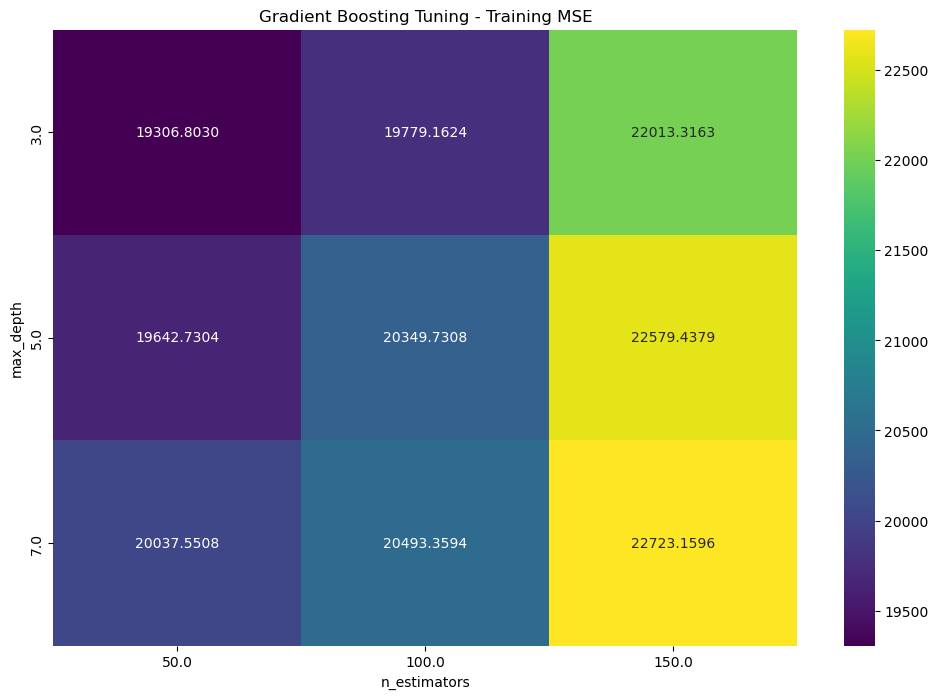

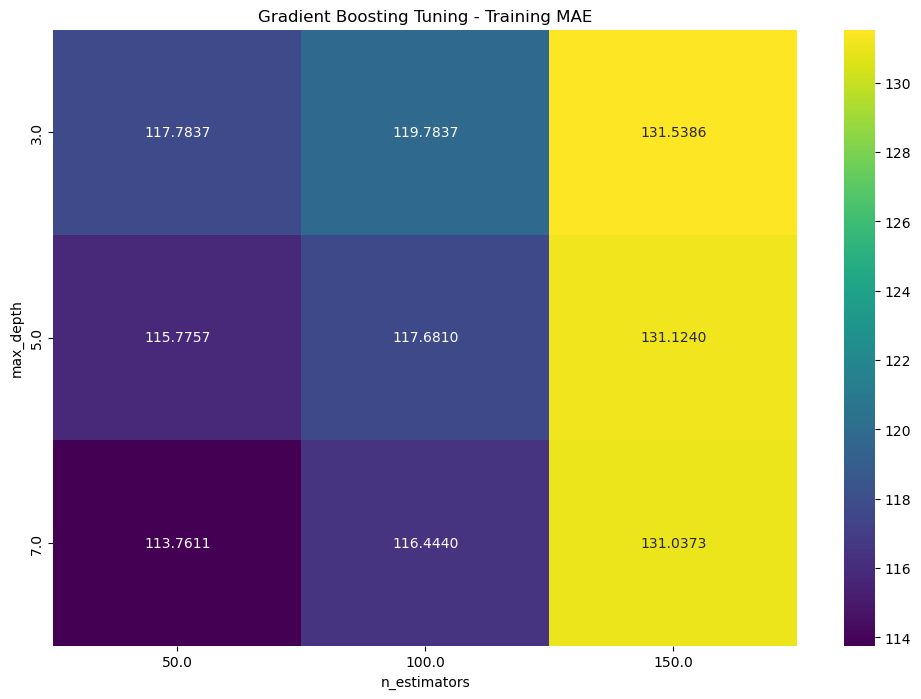

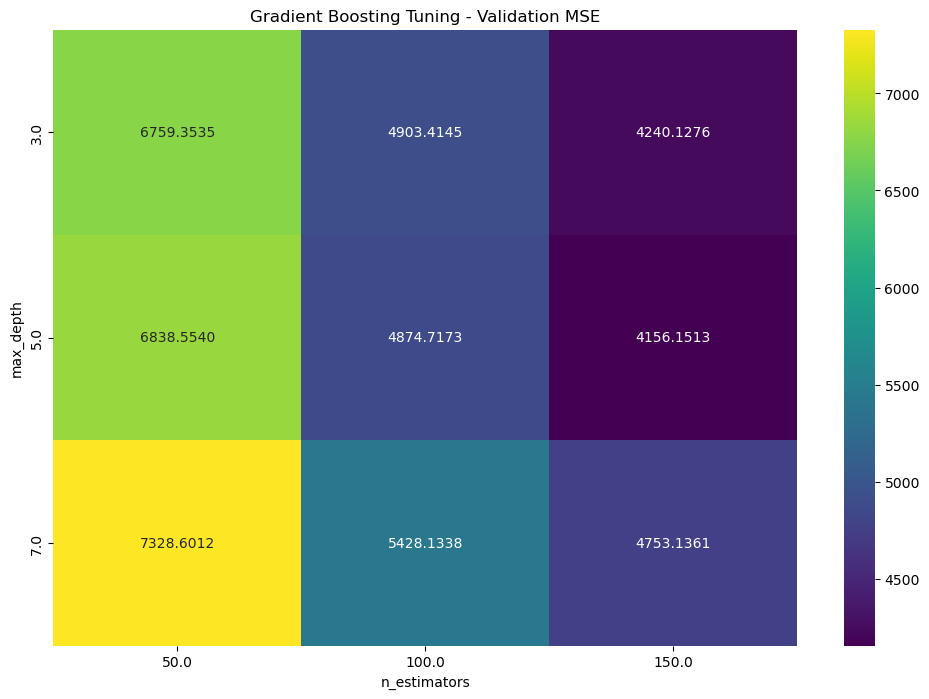

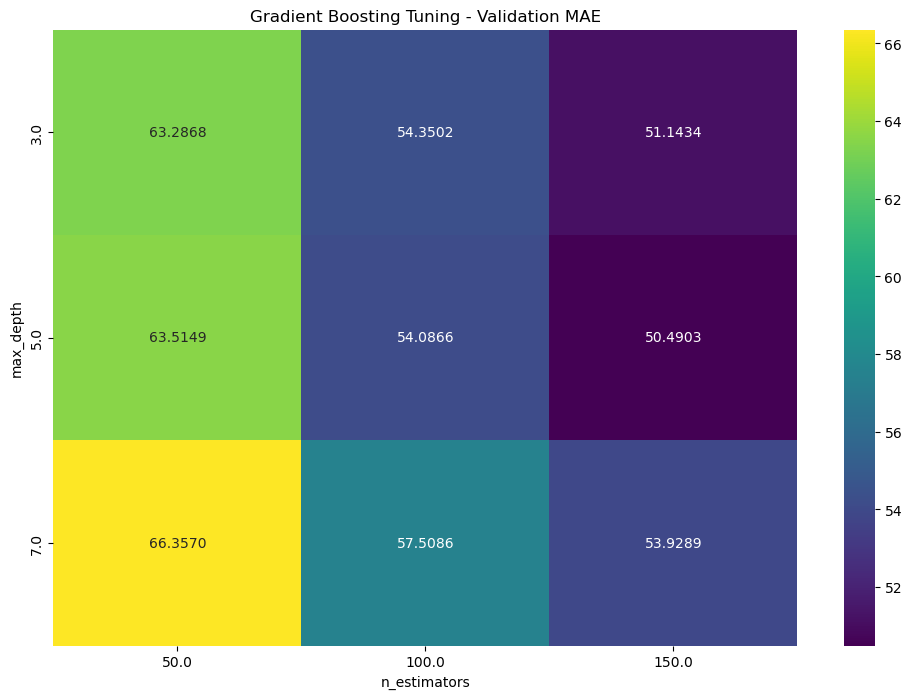

In [56]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap(results, title, x_label, y_label, z_label, error_type):
    
    unique_n_estimators = np.unique(results[:, 0])
    unique_max_depth = np.unique(results[:, 2])
    
    heatmap_data = np.zeros((len(unique_max_depth), len(unique_n_estimators)))
    
    for i, max_depth in enumerate(unique_max_depth):
        for j, n_estimators in enumerate(unique_n_estimators):
            mask = (results[:, 0] == n_estimators) & (results[:, 2] == max_depth)
            if np.any(mask):
                heatmap_data[i, j] = results[mask, error_type].mean()
    
    plt.figure(figsize=(12, 8))
    heatmap = sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='viridis',
                         xticklabels=unique_n_estimators, yticklabels=unique_max_depth)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    heatmap.set_xlabel(x_label)
    heatmap.set_ylabel(y_label)
    heatmap.set_title(title)
    plt.show()

plot_heatmap(gb_results, 
             title="Gradient Boosting Tuning - Training MSE", 
             x_label="n_estimators", 
             y_label="max_depth", 
             z_label="Training MSE", 
             error_type=3)  

plot_heatmap(gb_results, 
             title="Gradient Boosting Tuning - Training MAE", 
             x_label="n_estimators", 
             y_label="max_depth", 
             z_label="Training MAE", 
             error_type=4)  


plot_heatmap(gb_results, 
             title="Gradient Boosting Tuning - Validation MSE", 
             x_label="n_estimators", 
             y_label="max_depth", 
             z_label="Validation MSE", 
             error_type=5)  


plot_heatmap(gb_results, 
             title="Gradient Boosting Tuning - Validation MAE", 
             x_label="n_estimators", 
             y_label="max_depth", 
             z_label="Validation MAE", 
             error_type=6) 


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


In [58]:
def find_best_params(results, model_name, param_names):
    results = np.array(results)
    best_index = np.argmin(results[:, -2])  
    best_params = results[best_index, :-4]  
    
    best_mse_val = results[best_index, -2]
    best_mae_val = results[best_index, -1]
    
    print(f"Best parameters for {model_name}:")
    for param_name, param_value in zip(param_names, best_params):
        print(f"{param_name}: {param_value}")
    print(f"Best Validation MSE: {best_mse_val}")
    print(f"Best Validation MAE: {best_mae_val}")
    print("-" * 50)
    return best_params


In [59]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R^2': r2_score(y_test, y_pred),
    }
    
    return metrics


In [60]:
def evaluate_and_print_test_metrics(model, model_name, X_test, y_test):
    model.fit(X_train, y_train)  
    y_pred = model.predict(X_test) 

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{model_name} Test Metrics:")
    print(f"Test MSE: {mse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    print("-" * 50)


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_best_params = find_best_params(dt_results, "Decision Tree", ["max_depth"])
best_dt_model = DecisionTreeRegressor(max_depth=int(dt_best_params[0]))
evaluate_and_print_test_metrics(best_dt_model, "Decision Tree", X_test, y_test)

bagging_best_params = find_best_params(bagging_results, "Bagging Regressor", ["n_estimators"])
best_bagging_model = BaggingRegressor(DecisionTreeRegressor(max_depth=5), n_estimators=int(bagging_best_params[0]))
evaluate_and_print_test_metrics(best_bagging_model, "Bagging Regressor", X_test, y_test)

rf_best_params = find_best_params(rf_results, "Random Forest Regressor", ["n_estimators", "max_features"])
best_rf_model = RandomForestRegressor(n_estimators=int(rf_best_params[0]), max_depth=5, max_features=int(rf_best_params[1]))
evaluate_and_print_test_metrics(best_rf_model, "Random Forest Regressor", X_test, y_test)

gb_best_params = find_best_params(gb_results, "Gradient Boosting Regressor", ["n_estimators", "learning_rate", "max_depth"])
best_gb_model = GradientBoostingRegressor(n_estimators=int(gb_best_params[0]), learning_rate=gb_best_params[1], max_depth=int(gb_best_params[2]))
evaluate_and_print_test_metrics(best_gb_model, "Gradient Boosting Regressor", X_test, y_test)


Best parameters for Decision Tree:
max_depth: 2.0
Best Validation MSE: 3829.578959153463
Best Validation MAE: 50.2299801536014
--------------------------------------------------
Decision Tree Test Metrics:
Test MSE: 3866.0382
Test MAE: 50.0857
--------------------------------------------------
Best parameters for Bagging Regressor:
n_estimators: 20.0
Best Validation MSE: 3452.3621732355705
Best Validation MAE: 47.42671284409744
--------------------------------------------------
Bagging Regressor Test Metrics:
Test MSE: 2919.7722
Test MAE: 44.2541
--------------------------------------------------
Best parameters for Random Forest Regressor:
n_estimators: 20.0
max_features: 7.0
Best Validation MSE: 3360.7415982989924
Best Validation MAE: 47.71166462905751
--------------------------------------------------
Random Forest Regressor Test Metrics:
Test MSE: 2660.7185
Test MAE: 42.0202
--------------------------------------------------
Best parameters for Gradient Boosting Regressor:
n_estima

In [62]:
dt_metrics = evaluate_model(best_dt_model, X_train, y_train, X_test, y_test)
bagging_metrics = evaluate_model(best_bagging_model, X_train, y_train, X_test, y_test)
rf_metrics = evaluate_model(best_rf_model, X_train, y_train, X_test, y_test)
gb_metrics = evaluate_model(best_gb_model, X_train, y_train, X_test, y_test)


Decision Tree Metrics:
MAE: 145.5962
MSE: 26353.5982
RMSE: 162.3379
R²: -3.9741

Bagging Metrics:
MAE: 145.5019
MSE: 26331.0881
RMSE: 162.2686
R²: -3.9699

Random Forest Metrics:
MAE: 145.9790
MSE: 26476.9191
RMSE: 162.7173
R²: -3.9974

Gradient Boosting Metrics:
MAE: 144.2326
MSE: 25935.0816
RMSE: 161.0437
R²: -3.8951



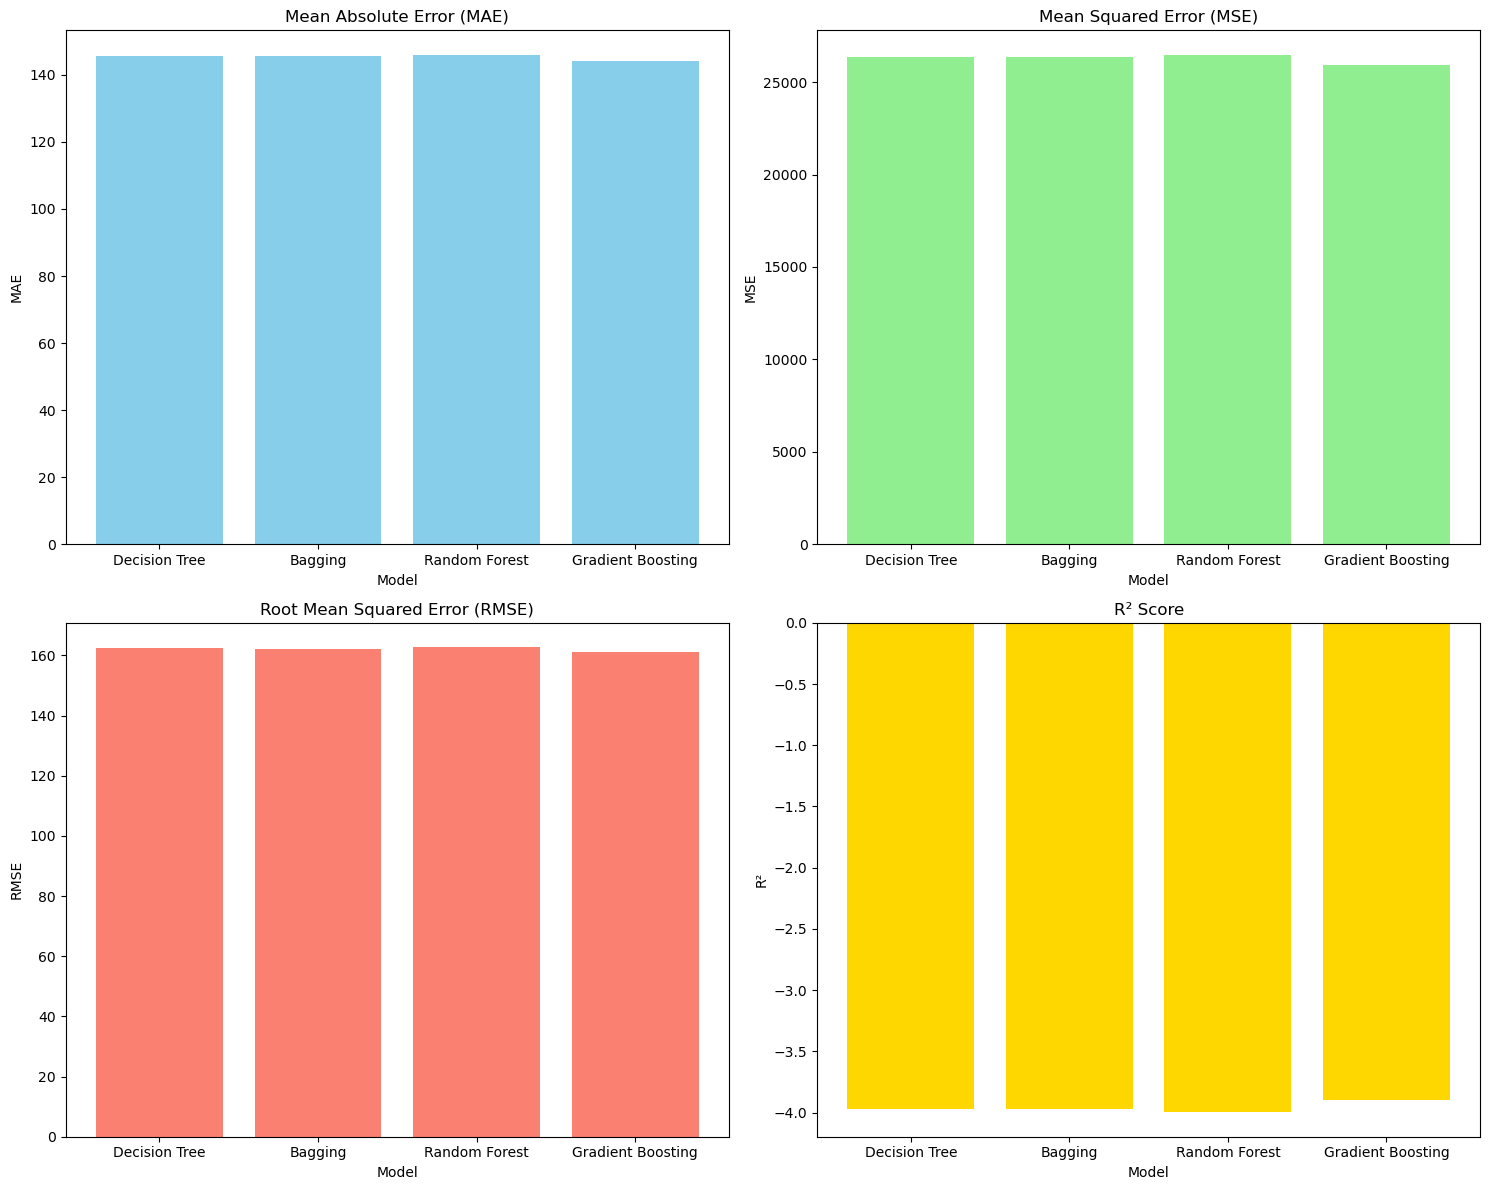

In [63]:
print("Decision Tree Metrics:")
print(f"MAE: {dt_metrics['MAE']:.4f}")
print(f"MSE: {dt_metrics['MSE']:.4f}")
print(f"RMSE: {dt_metrics['RMSE']:.4f}")
print(f"R²: {dt_metrics['R^2']:.4f}\n")

print("Bagging Metrics:")
print(f"MAE: {bagging_metrics['MAE']:.4f}")
print(f"MSE: {bagging_metrics['MSE']:.4f}")
print(f"RMSE: {bagging_metrics['RMSE']:.4f}")
print(f"R²: {bagging_metrics['R^2']:.4f}\n")

print("Random Forest Metrics:")
print(f"MAE: {rf_metrics['MAE']:.4f}")
print(f"MSE: {rf_metrics['MSE']:.4f}")
print(f"RMSE: {rf_metrics['RMSE']:.4f}")
print(f"R²: {rf_metrics['R^2']:.4f}\n")

print("Gradient Boosting Metrics:")
print(f"MAE: {gb_metrics['MAE']:.4f}")
print(f"MSE: {gb_metrics['MSE']:.4f}")
print(f"RMSE: {gb_metrics['RMSE']:.4f}")
print(f"R²: {gb_metrics['R^2']:.4f}\n")


models = ['Decision Tree', 'Bagging', 'Random Forest', 'Gradient Boosting']
mae = [dt_metrics['MAE'], bagging_metrics['MAE'], rf_metrics['MAE'], gb_metrics['MAE']]
mse = [dt_metrics['MSE'], bagging_metrics['MSE'], rf_metrics['MSE'], gb_metrics['MSE']]
rmse = [dt_metrics['RMSE'], bagging_metrics['RMSE'], rf_metrics['RMSE'], gb_metrics['RMSE']]
r2 = [dt_metrics['R^2'], bagging_metrics['R^2'], rf_metrics['R^2'], gb_metrics['R^2']]


fig, axs = plt.subplots(2, 2, figsize=(15, 12))


axs[0, 0].bar(models, mae, color='skyblue')
axs[0, 0].set_title('Mean Absolute Error (MAE)')
axs[0, 0].set_ylabel('MAE')
axs[0, 0].set_xlabel('Model')


axs[0, 1].bar(models, mse, color='lightgreen')
axs[0, 1].set_title('Mean Squared Error (MSE)')
axs[0, 1].set_ylabel('MSE')
axs[0, 1].set_xlabel('Model')


axs[1, 0].bar(models, rmse, color='salmon')
axs[1, 0].set_title('Root Mean Squared Error (RMSE)')
axs[1, 0].set_ylabel('RMSE')
axs[1, 0].set_xlabel('Model')


axs[1, 1].bar(models, r2, color='gold')
axs[1, 1].set_title('R² Score')
axs[1, 1].set_ylabel('R²')
axs[1, 1].set_xlabel('Model')

plt.tight_layout()
plt.show()


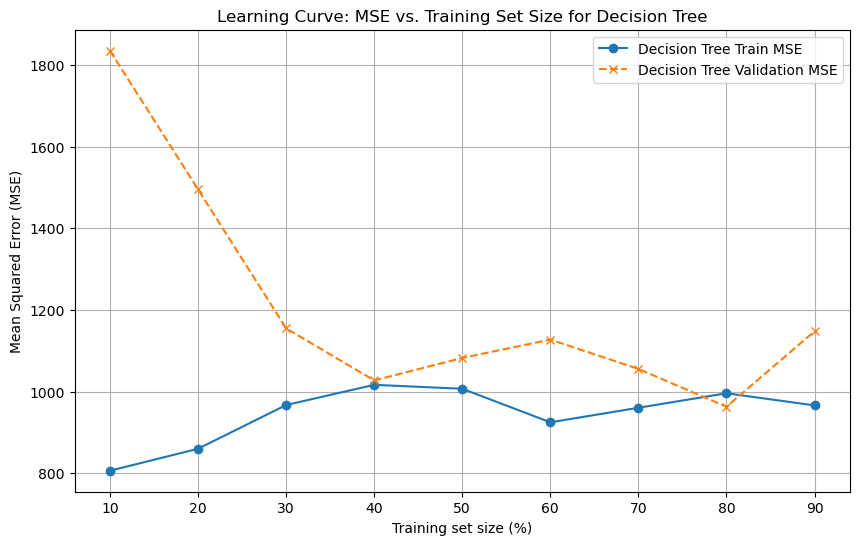

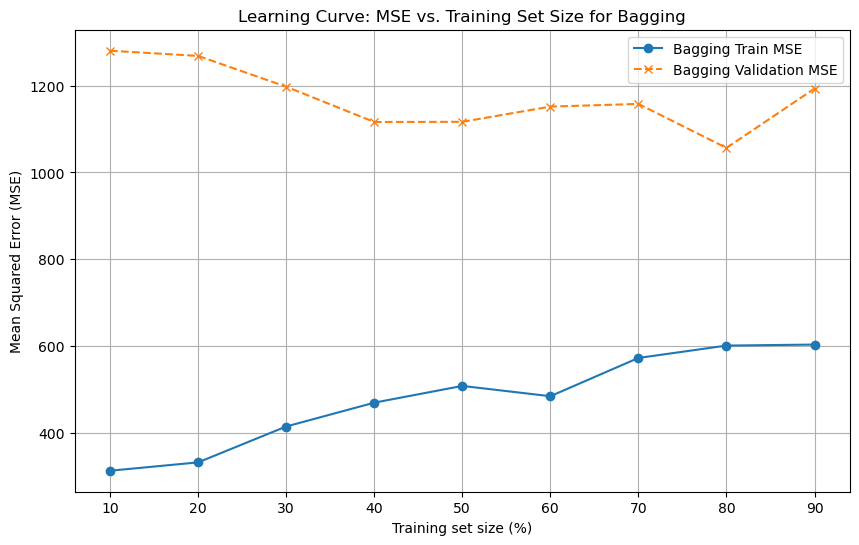

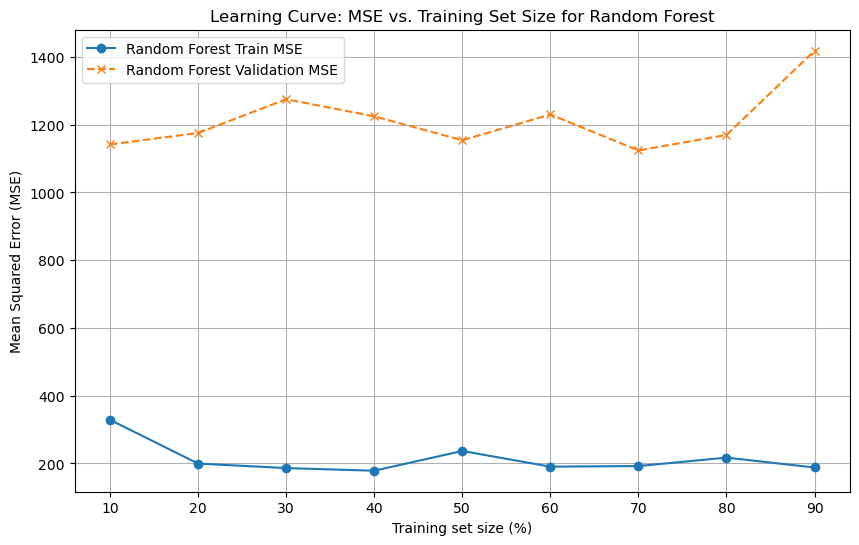

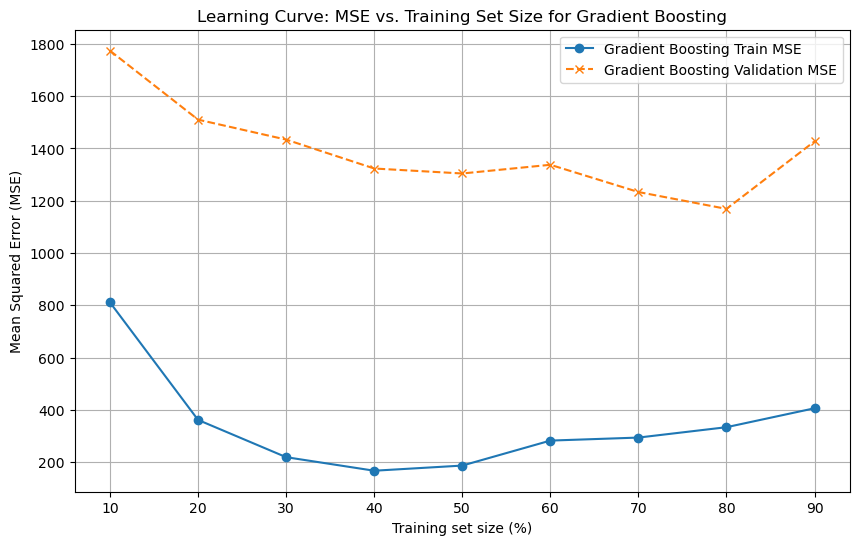

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from itertools import product
from sklearn.metrics import mean_squared_error


def plot_learning_curve_mse_separate(models, param_grids, X_train, y_train):
    train_sizes = np.linspace(0.1, 0.9, 9)

    for model_name, model in models.items():
        param_grid = param_grids[model_name]
        best_train_errors = []
        best_val_errors = []

        plt.figure(figsize=(10, 6))

        for train_size in train_sizes:
            X_train_subset, X_val, y_train_subset, y_val = train_test_split(X_train, y_train, train_size=train_size, random_state=42)
            
            
            param_values = list(product(*param_grid.values()))[0]  
            
            
            if model_name == 'Bagging':
                model_instance = model.__class__(base_estimator=DecisionTreeRegressor(max_depth=5), **dict(zip(param_grid.keys(), param_values)))
            else:
                model_instance = model.__class__(**dict(zip(param_grid.keys(), param_values)))
            
            
            model_instance.fit(X_train_subset, y_train_subset)
            y_train_pred = model_instance.predict(X_train_subset)
            y_val_pred = model_instance.predict(X_val)
            
            train_score = mean_squared_error(y_train_subset, y_train_pred)
            val_score = mean_squared_error(y_val, y_val_pred)

            best_train_errors.append(train_score)
            best_val_errors.append(val_score)

        plt.plot(train_sizes * 100, best_train_errors, label=f'{model_name} Train MSE', marker='o')
        plt.plot(train_sizes * 100, best_val_errors, label=f'{model_name} Validation MSE', linestyle='--', marker='x')

        plt.title(f'Learning Curve: MSE vs. Training Set Size for {model_name}')
        plt.xlabel('Training set size (%)')
        plt.ylabel('Mean Squared Error (MSE)')
        plt.legend()
        plt.grid(True)
        plt.show()


models = {
    'Decision Tree': DecisionTreeRegressor(max_depth=5),
    'Bagging': BaggingRegressor(base_estimator=DecisionTreeRegressor(max_depth=5), n_estimators=10),
    'Random Forest': RandomForestRegressor(n_estimators=10, max_depth=5, max_features=5),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
}


param_grids = {
    'Decision Tree': {'max_depth': [2]},
    'Bagging': {'n_estimators': [25]},
    'Random Forest': {'n_estimators': [30], 'max_features': [7]},
    'Gradient Boosting': {'n_estimators': [50], 'learning_rate': [0.1], 'max_depth': [3]}
}

plot_learning_curve_mse_separate(models, param_grids, X_train, y_train)
